<a href="https://colab.research.google.com/github/SamaTawfik/Deep-Learning-Image-Classification-Project/blob/main/MNIST_DL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [194]:
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
import torch.optim as optim

from torch.utils.data import DataLoader, Subset

import matplotlib.pyplot as plt
import pandas as pd
import random

In [195]:
torch.manual_seed(42)
random.seed(42)
##Hyperparameters
batch_size = 64
learning_rate = 0.0008
epochs = 5
##Transform
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [196]:
##Dataset
full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

full_test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=transform,
    download=True
)

##Take a Subset
train_indices = list(range(6000))
test_indices = list(range(1200))

train_dataset = Subset(full_train_dataset, train_indices)
test_dataset = Subset(full_test_dataset, test_indices)


train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

##Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)


Using device: cpu


In [197]:
#==========RESNET==========
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):

        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:

            self.shortcut = nn.Sequential(

                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride
                ),

                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):

        out = torch.relu(self.bn1(self.conv1(x)))

        out = self.bn2(self.conv2(out))

        out += self.shortcut(x)

        return torch.relu(out)

class SimpleResNet(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.conv1 = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU()
        )

        self.layer1 = nn.Sequential(
            ResidualBlock(32, 32),
            ResidualBlock(32, 32)
        )

        self.layer2 = nn.Sequential(
            ResidualBlock(32, 64, stride=2),
            ResidualBlock(64, 64)
        )

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):

        x = self.conv1(x)

        x = self.layer1(x)

        x = self.layer2(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.dropout(x)

        return self.fc(x)



In [198]:
#==========GOOGLRNET==========
class InceptionBlock(nn.Module):

    def __init__(self, in_channels):

        super().__init__()

        self.b1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 1),
            nn.ReLU()
        )

        self.b2 = nn.Sequential(
            nn.Conv2d(in_channels, 32, 1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU()
        )

        self.b3 = nn.Sequential(
            nn.Conv2d(in_channels, 16, 1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 5, padding=2),
            nn.ReLU()
        )

        self.b4 = nn.Sequential(
            nn.MaxPool2d(3, stride=1, padding=1),
            nn.Conv2d(in_channels, 32, 1),
            nn.ReLU()
        )

    def forward(self, x):

        return torch.cat([
            self.b1(x),
            self.b2(x),
            self.b3(x),
            self.b4(x)
        ], dim=1)

class SimpleGoogLeNet(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.conv1 = nn.Sequential(

            nn.Conv2d(3, 32, 3, padding=1),

            nn.BatchNorm2d(32),

            nn.ReLU()
        )

        self.inception1 = InceptionBlock(32)

        self.inception2 = InceptionBlock(160)
        self.inception3 = InceptionBlock(160)

        self.maxpool = nn.MaxPool2d(2,2)

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.3)


        self.fc = nn.Linear(160, num_classes)

    def forward(self, x):

        x = self.conv1(x)

        x = self.inception1(x)
        x = self.maxpool(x)

        x = self.inception2(x)
        x = self.maxpool(x)

        x = self.inception3(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.dropout(x)

        return self.fc(x)

In [199]:
#==========DENSENET==========
class DenseLayer(nn.Module):

    def __init__(self, in_channels, growth_rate):

        super().__init__()

        self.layer = nn.Sequential(

            nn.BatchNorm2d(in_channels),

            nn.ReLU(),

            nn.Conv2d(
                in_channels,
                growth_rate,
                kernel_size=3,
                padding=1
            )
        )

    def forward(self, x):

        new_features = self.layer(x)

        return torch.cat([x, new_features], dim=1)

class SimpleDenseNet(nn.Module):

    def __init__(self, num_classes=10):

        super().__init__()

        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)

        self.dense1 = DenseLayer(32, 32)

        self.dense2 = DenseLayer(64, 32)

        self.dense3 = DenseLayer(96, 32)
        self.maxpool = nn.MaxPool2d(2,2)

        self.pool = nn.AdaptiveAvgPool2d((1,1))

        self.dropout = nn.Dropout(0.3)

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):

        x = self.conv1(x)

        x = self.dense1(x)
        x = self.maxpool(x)

        x = self.dense2(x)
        x = self.maxpool(x)

        x = self.dense3(x)

        x = self.pool(x)

        x = torch.flatten(x,1)

        x = self.dropout(x)

        return self.fc(x)

In [200]:
def train_and_evaluate(model, model_name):

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        model.parameters(),
        lr=learning_rate
    )

    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    print("\n" + "="*50)
    print(f"Training {model_name}")
    print("="*50)

    for epoch in range(epochs):

        model.train()

        running_loss = 0

        correct = 0
        total = 0

        for imgs, labels in train_loader:

            imgs = imgs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(imgs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()

            total += labels.size(0)

        train_acc = 100 * correct / total

        train_loss = running_loss / len(train_loader)

        train_losses.append(train_loss)

        train_accuracies.append(train_acc)

        # TEST

        model.eval()

        correct = 0
        total = 0

        running_test_loss = 0

        with torch.no_grad():

            for imgs, labels in test_loader:

                imgs = imgs.to(device)
                labels = labels.to(device)

                outputs = model(imgs)

                loss = criterion(outputs, labels)

                running_test_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)

                correct += (preds == labels).sum().item()

                total += labels.size(0)

        test_acc = 100 * correct / total

        test_loss = running_test_loss / len(test_loader)

        test_losses.append(test_loss)

        test_accuracies.append(test_acc)

        print(
            f"{model_name} | "
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Test Acc: {test_acc:.2f}%"
        )

    return {
        "model_name": model_name,
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies,
        "final_accuracy": test_acc
    }

In [201]:
    # #==========VISYALIZATION==========
    # plt.figure(figsize=(10, 4))
    # plt.plot(train_losses, label="Train Loss")
    # plt.plot(test_losses, label="Test Loss")
    # plt.title(f"{model_name} Loss Curve")
    # plt.xlabel("Epoch")
    # plt.ylabel("Loss")
    # plt.legend()
    # plt.show()

    # plt.figure(figsize=(10, 4))
    # plt.plot(train_accuracies, label="Train Accuracy")
    # plt.plot(test_accuracies, label="Test Accuracy")
    # plt.title(f"{model_name} Accuracy Curve")
    # plt.xlabel("Epoch")
    # plt.ylabel("Accuracy")
    # plt.legend()
    # plt.show()

    # return test_acc, test_loss

In [202]:
##INITIALIZE
resnet = SimpleResNet().to(device)

googlenet = SimpleGoogLeNet().to(device)

densenet = SimpleDenseNet().to(device)

##RUN
resnet_results = train_and_evaluate(
    resnet,
    "ResNet"
)

googlenet_results = train_and_evaluate(
    googlenet,
    "GoogLeNet"
)

densenet_results = train_and_evaluate(
    densenet,
    "DenseNet"
)


Training ResNet
ResNet | Epoch [1/5] | Train Acc: 66.38% | Test Acc: 67.42%
ResNet | Epoch [2/5] | Train Acc: 92.50% | Test Acc: 93.08%
ResNet | Epoch [3/5] | Train Acc: 94.90% | Test Acc: 92.67%
ResNet | Epoch [4/5] | Train Acc: 95.88% | Test Acc: 84.33%
ResNet | Epoch [5/5] | Train Acc: 96.55% | Test Acc: 95.33%

Training GoogLeNet
GoogLeNet | Epoch [1/5] | Train Acc: 25.18% | Test Acc: 52.08%
GoogLeNet | Epoch [2/5] | Train Acc: 63.55% | Test Acc: 83.33%
GoogLeNet | Epoch [3/5] | Train Acc: 84.55% | Test Acc: 88.67%
GoogLeNet | Epoch [4/5] | Train Acc: 90.18% | Test Acc: 92.00%
GoogLeNet | Epoch [5/5] | Train Acc: 91.48% | Test Acc: 93.42%

Training DenseNet
DenseNet | Epoch [1/5] | Train Acc: 32.00% | Test Acc: 45.92%
DenseNet | Epoch [2/5] | Train Acc: 57.52% | Test Acc: 71.25%
DenseNet | Epoch [3/5] | Train Acc: 73.73% | Test Acc: 76.83%
DenseNet | Epoch [4/5] | Train Acc: 81.67% | Test Acc: 80.25%
DenseNet | Epoch [5/5] | Train Acc: 85.92% | Test Acc: 88.08%


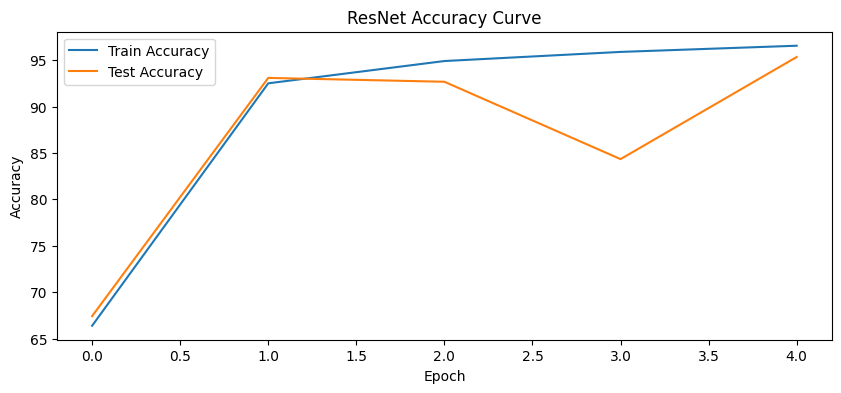

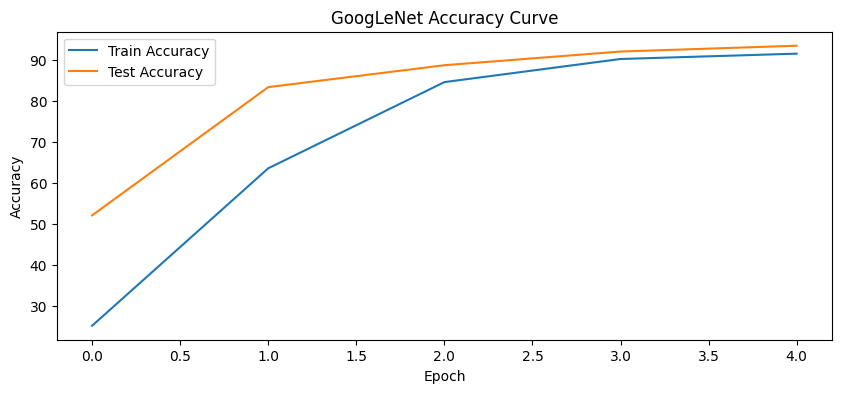

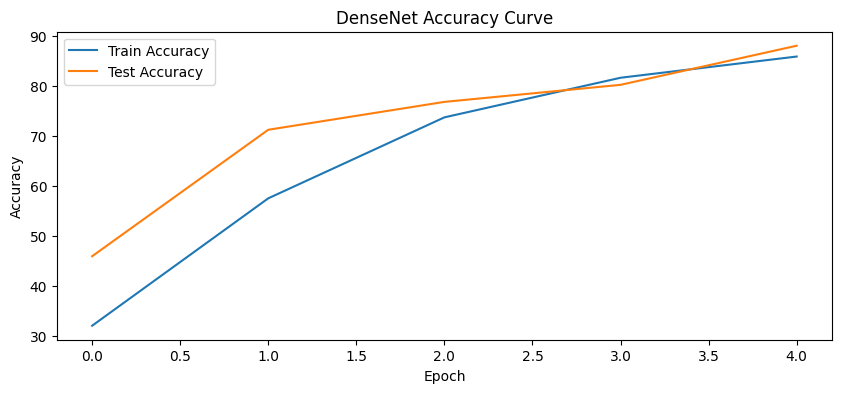

In [206]:
#===========VISUALIZATION=========
def plot_results(results):

    model_name = results["model_name"]

    plt.figure(figsize=(10,4))

    plt.plot(results["train_accuracies"], label="Train Accuracy")

    plt.plot(results["test_accuracies"], label="Test Accuracy")

    plt.title(f"{model_name} Accuracy Curve")

    plt.xlabel("Epoch")

    plt.ylabel("Accuracy")

    plt.legend()

    plt.show()

plot_results(resnet_results)

plot_results(googlenet_results)

plot_results(densenet_results)

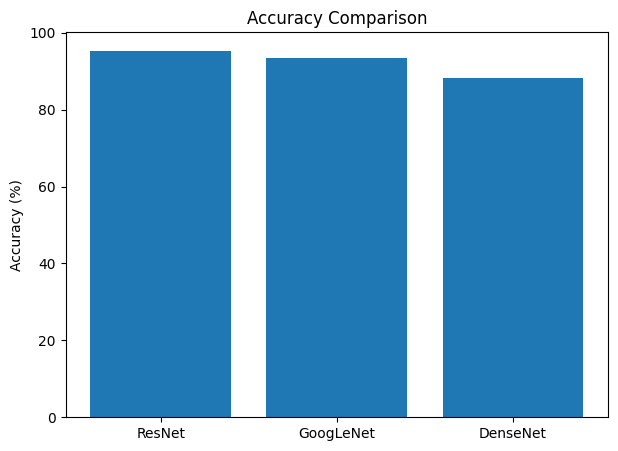

In [207]:

# BAR CHART COMPARISON

models = ["ResNet", "GoogLeNet", "DenseNet"]

accuracies = [
    resnet_results["final_accuracy"],
    googlenet_results["final_accuracy"],
    densenet_results["final_accuracy"]
]

plt.figure(figsize=(7,5))

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")

plt.ylabel("Accuracy (%)")

plt.show()

In [208]:
print("\nFINAL RESULT\n")

print(f"ResNet Accuracy     : {resnet_results['final_accuracy']:.2f}%")

print(f"GoogLeNet Accuracy  : {googlenet_results['final_accuracy']:.2f}%")

print(f"DenseNet Accuracy   : {densenet_results['final_accuracy']:.2f}%")


FINAL RESULT

ResNet Accuracy     : 95.33%
GoogLeNet Accuracy  : 93.42%
DenseNet Accuracy   : 88.08%
